# 01 — PICS Data Exploration (Simulated)
Goal: load and inspect ECG/respiration signals. Uses neurokit2 simulated data (500Hz) while PICS downloads.
Same structure and pipeline as real data.

In [4]:
import neurokit2 as nk
import matplotlib.pyplot as plt
import numpy as np

## 1. Generate simulated data (replaces file loading)
Same 500Hz sampling rate and 60s duration as PICS pipeline.
ECG at 500Hz, respiration at 50Hz to match signal structure.

In [5]:
ecg_raw = nk.ecg_simulate(duration=60, sampling_rate=500)
respiration = nk.rsp_simulate(duration=60, sampling_rate=50)
fs = 500

print('Sampling frequency:', fs, 'Hz')
print('Channels: ECG (500Hz), RESP (50Hz)')
print('ECG shape:', ecg_raw.shape)
print('Respiration shape:', respiration.shape)

Sampling frequency: 500 Hz
Channels: ECG (500Hz), RESP (50Hz)
ECG shape: (30000,)
Respiration shape: (3000,)


## 2. Extract and prepare signals
ECG at 500Hz, respiration at 50Hz. Build time axes for plotting.

In [6]:
ecg = ecg_raw
time = np.arange(len(ecg)) / fs

print(f'ECG: {len(ecg)} samples = {len(ecg)/fs:.1f} seconds')

ECG: 30000 samples = 60.0 seconds


## 3. Plot the raw ECG and respiration
You should see clear QRS peaks (sharp spikes) — those are heartbeats.

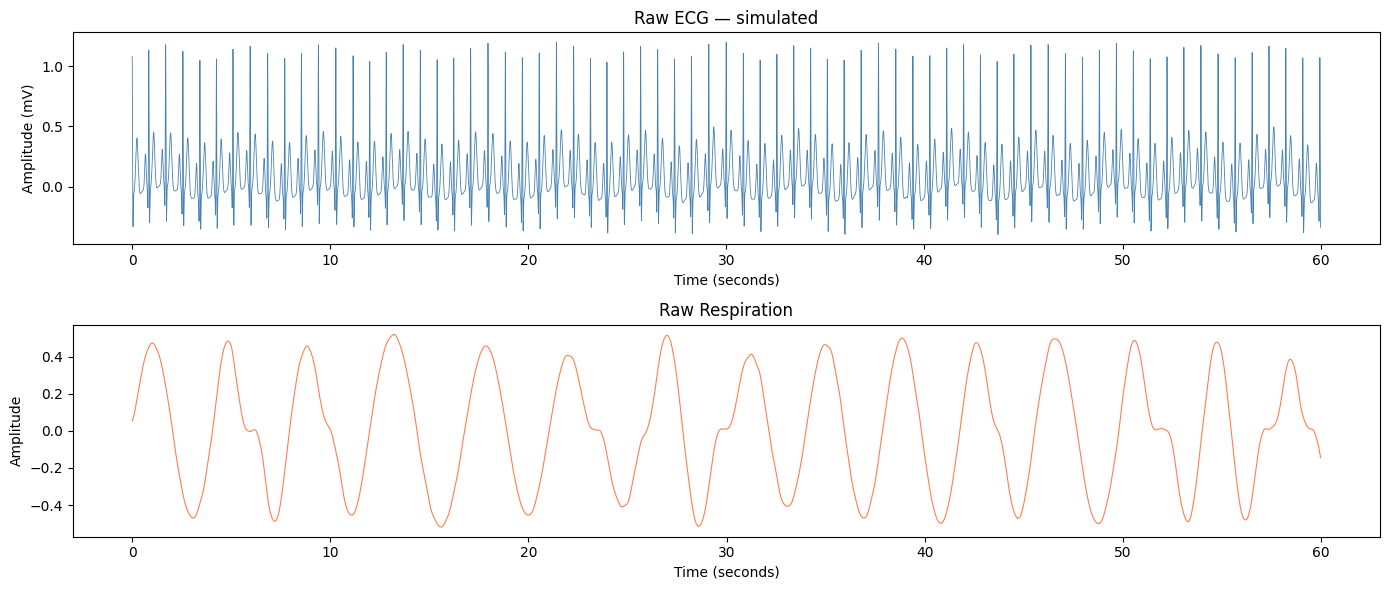

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

axes[0].plot(time, ecg, color='steelblue', linewidth=0.6)
axes[0].set_title('Raw ECG — simulated')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].set_xlabel('Time (seconds)')

resp_time = np.arange(len(respiration)) / 50
axes[1].plot(resp_time, respiration, color='coral', linewidth=0.8)
axes[1].set_title('Raw Respiration')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.show()

## 4. Sanity check — basic stats
Look for NaNs, flat lines, or extreme values.

In [8]:
print('=== ECG ===')
print(f'  Min: {ecg.min():.4f}')
print(f'  Max: {ecg.max():.4f}')
print(f'  Mean: {ecg.mean():.4f}')
print(f'  Std: {ecg.std():.4f}')
print(f'  NaNs: {np.isnan(ecg).sum()}')

print('\n=== Respiration ===')
print(f'  Min: {respiration.min():.4f}')
print(f'  Max: {respiration.max():.4f}')
print(f'  NaNs: {np.isnan(respiration).sum()}')

=== ECG ===
  Min: -0.3969
  Max: 1.2001
  Mean: 0.0900
  Std: 0.2353
  NaNs: 0

=== Respiration ===
  Min: -0.5185
  Max: 0.5188
  NaNs: 0


## 5. Loop over 10 simulated infants — compare signal quality
Simulate 10 signals with varying heart rates (120–180 bpm) to mirror PICS structure.

In [9]:
print(f"{'Record':<15} {'Duration (min)':<18} {'ECG Std':<12} {'NaNs'}")
print('-' * 55)

for i in range(1, 11):
    record_name = f'simulated_{i}'
    ecg_full = nk.ecg_simulate(duration=60, sampling_rate=500, heart_rate=120 + 6 * i)
    duration_min = len(ecg_full) / fs / 60
    print(f'{record_name:<15} {duration_min:<18.1f} {ecg_full.std():<12.4f} {np.isnan(ecg_full).sum()}')

Record          Duration (min)     ECG Std      NaNs
-------------------------------------------------------
simulated_1     1.0                0.2544       0
simulated_2     1.0                0.2577       0
simulated_3     1.0                0.2577       0
simulated_4     1.0                0.2605       0
simulated_5     1.0                0.2609       0
simulated_6     1.0                0.2625       0
simulated_7     1.0                0.2390       0
simulated_8     1.0                0.2384       0
simulated_9     1.0                0.2641       0
simulated_10    1.0                0.2648       0
